<a href="https://colab.research.google.com/github/hoshi-3104-com/california-house-price-competition/blob/main/notebooks/02_house_price_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 02. 特徴量の前処理&生成

#### 1. 本ファイルの目的
探索的データ解析（EDA）のフェーズで得られた知見に基づき、機械学習モデルの予測精度を最大限に引き出すための「データの前処理」および「高度な特徴量生成（Feature Engineering）」を体系的に行うことである。

#### 2. 前処理のアプローチ（やること）
本ファイルでは、以下の5つのアプローチでデータの前処理と特徴量の大幅な拡張を行う。

① 外部環境のセットアップと生データの読み込み
Google Driveのマウント、Kaggle APIの設定、および前ステージで保存した生の訓練データ・テストデータを読み込む。

② 統計分析に基づく外れ値の特定と除去
EDA段階で判明した異常値（AveBedrms, Population, AveOccup などの極端な値）を散布図で視覚的に再確認し、モデルの学習を阻害する行を特定して除去（フィルタリング）する。

③ ドメイン知識および地理統計に基づく高度な特徴量生成（Feature Engineering）
住宅の構造（部屋・寝室比率、密集度）、主要都市や施設（LA、SF、SD、名門大学、治安リスク地域、断層、軍事基地、港、シリコンバレー、メキシコ国境など）への球面距離、大気汚染スコア、ガウス混合モデル（GMM）によるエリアクラスタリングなど、100を超える高度な特徴量を一元的に生成・拡張する。

④ 機械学習モデルを用いた富裕層確率（メタ特徴量）のスタッキング
LightGBMの分類モデルを用い、高額住宅（富裕層エリア）に該当する確率を5分割交差検証（5-Fold CV）によるOOF（Out-Of-Fold）予測で算出し、強力なメタ特徴量としてデータセットに追加する。

⑤ 目的変数のスケーリング（対数変換）とデータ保存
目的変数（Price）に対して分布の歪みを解消する対数変換（log1p）を施し、最終的に生成された高品質な前処理済みデータセットをCSVファイルとして保存する。

##### ① 環境構築・データの読み込み

In [3]:
!pip install uv
!uv pip install --system optuna catboost kaggle

Using Python 3.12.13 environment at: /usr
Resolved 55 packages in 502ms                                        
Prepared 1 package in 1.47s                                              
Installed 1 package in 4ms                                  
 + catboost==1.2.10


In [4]:
# driveのマウント
from google.colab import drive
drive.mount('/content/drive')

# Kaggle APIを利用できるようにするため、kaggle.jsonからusernameとkeyを設定する
import os
import json
f = open("/content/drive/MyDrive/house_price_competition_hoshino/kaggle.json", 'r') # ディレクトリは必要に応じて変更してください
json_data = json.load(f)
os.environ['KAGGLE_USERNAME'] = json_data['username']
os.environ['KAGGLE_KEY'] = json_data['key']

# 標準ライブラリのインポート
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# グラフをアウトプット行に出力するためのマジックコマンド
%matplotlib inline

Mounted at /content/drive


In [5]:
#　データの読み込み
train = pd.read_csv('/content/drive/MyDrive/house_price_competition_hoshino/data/train_data_raw.csv')
test = pd.read_csv('/content/drive/MyDrive/house_price_competition_hoshino/data/test_data_raw.csv')
sample = pd.read_csv('/content/drive/MyDrive/house_price_competition_hoshino/data/sample_raw.csv')

#### ②外れ値の特定と除去

##### 2-1 外れ値の確認

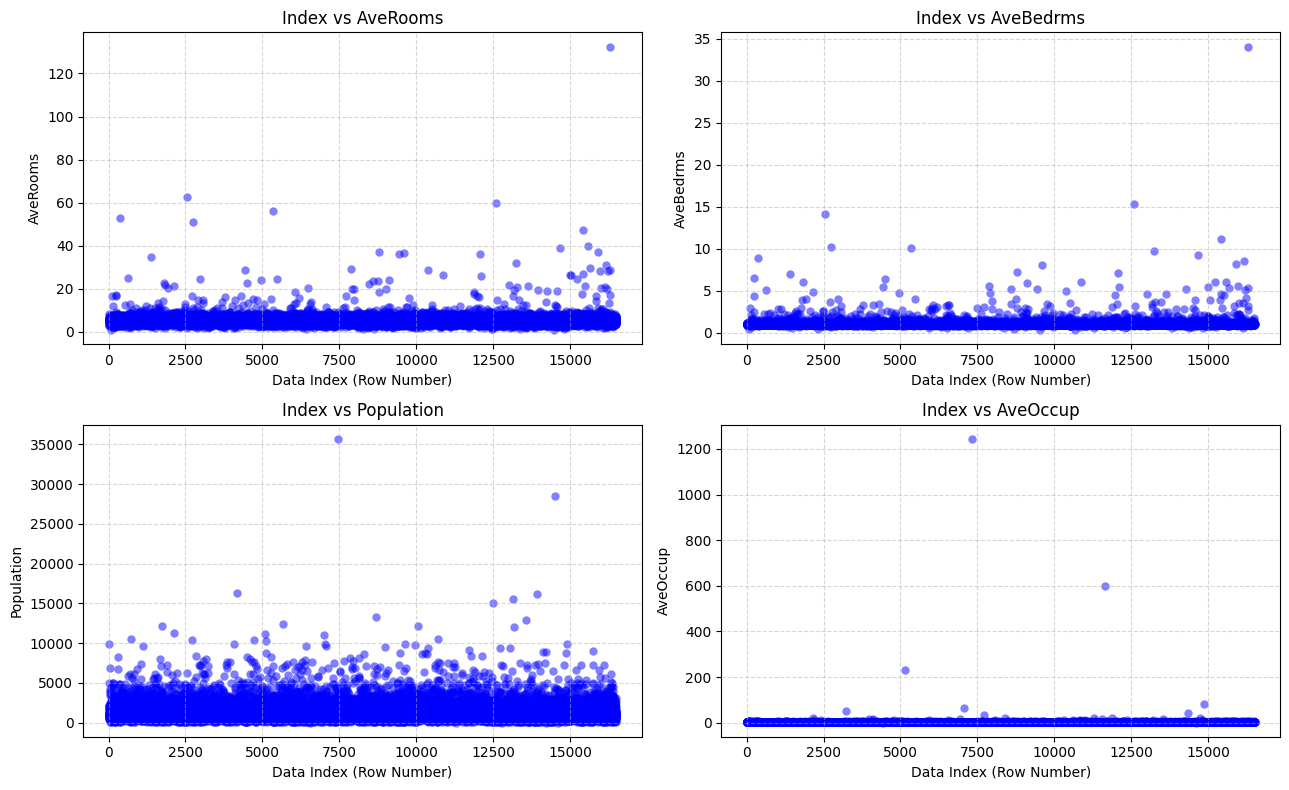

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 対象の特徴量リスト
features = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']

# 1. グラフ描画（2行2列の散布図を作成）
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for i, col in enumerate(features):
    row = i // 2
    ax = axes[row, i % 2]

    # 横軸：インデックス（行番号）、縦軸：特徴量の値 で散布図を描画
    sns.scatterplot(data=train, x=train.index, y=col, ax=ax, color='blue', alpha=0.5, linewidth=0)
    ax.set_title(f'Index vs {col}', fontsize=12)
    ax.set_xlabel('Data Index (Row Number)')
    ax.set_ylabel(col)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


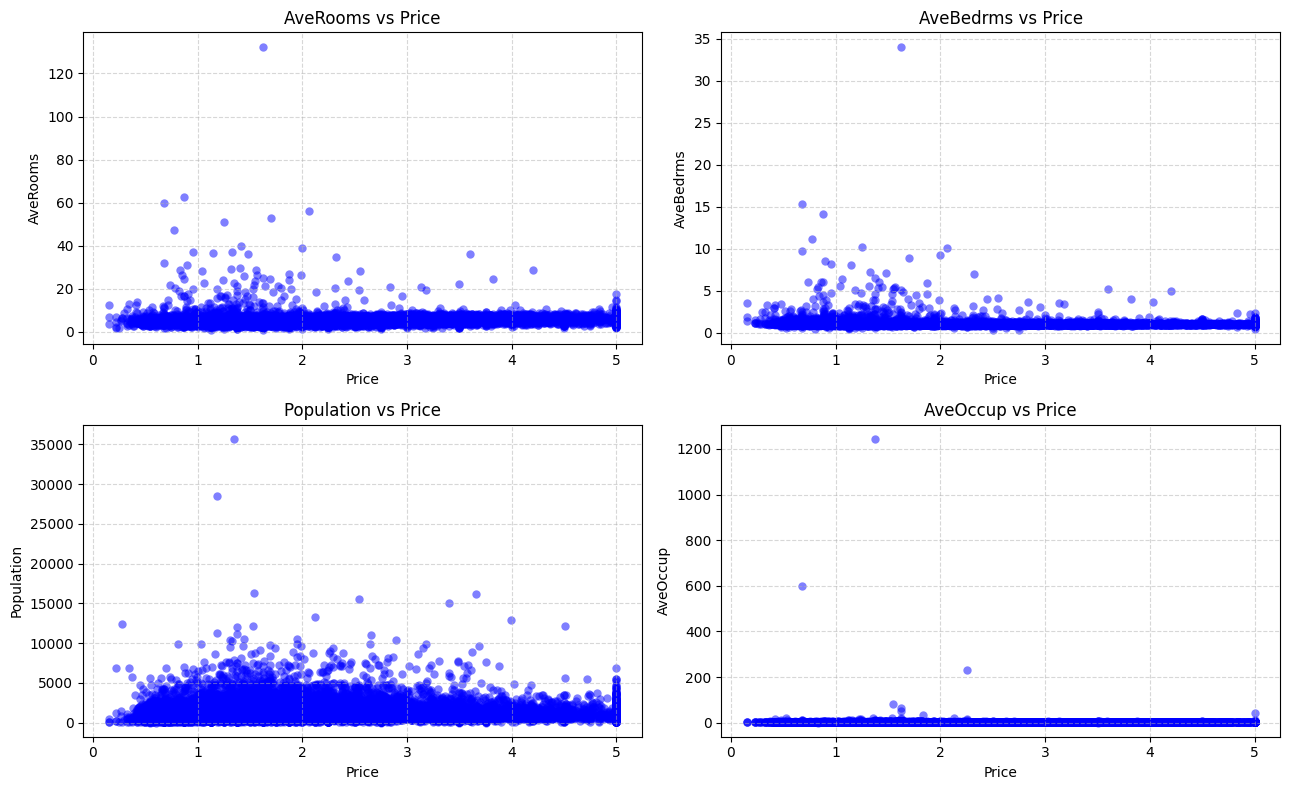

In [ ]:
# 1.　グラフ描画（2行2列の散布図を作成）
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for i, col in enumerate(features):
    row = i // 2
    ax = axes[row, i % 2]

    # ★変更点：横軸(x)に各特徴量、縦軸(y)に Price を指定
    sns.scatterplot(data=train, x='Price', y=col, ax=ax, color='blue', alpha=0.5, linewidth=0)
    ax.set_title(f'{col} vs Price', fontsize=12)
    ax.set_xlabel('Price')                  # 横軸のラベルを特徴量名に
    ax.set_ylabel(col)              # 縦軸のラベルを Price に
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##### 2-2 外れ値の特定＆除去

In [13]:
# 外れ値の特定
outlier_data = train[train['AveRooms'] > 120]
display(outlier_data)
outlier_data = train[train['AveBedrms'] > 30]
display(outlier_data)
outlier_data = train[train['Population'] > 25000]
display(outlier_data)
outlier_data = train[train['AveOccup'] > 200]
display(outlier_data)

,id,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Household,AllRooms,AllBedrms,Price
16293,16293,4.625,34.0,132.533333,34.066667,36.0,2.4,38.8,-120.08,15.0,1988.0,511.0,1.625


,id,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Household,AllRooms,AllBedrms,Price
16293,16293,4.625,34.0,132.533333,34.066667,36.0,2.4,38.8,-120.08,15.0,1988.0,511.0,1.625


,id,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Household,AllRooms,AllBedrms,Price
7471,7471,2.5729,14.0,5.270497,1.010484,35682.0,7.482072,33.35,-117.42,4769.0,25135.0,4819.0,1.344
14503,14503,2.3087,11.0,5.364518,1.059684,28566.0,4.696810,36.64,-121.79,6082.0,32627.0,6445.0,1.188


,id,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Household,AllRooms,AllBedrms,Price
5136,5136,6.1359,52.0,8.275862,1.517241,6675.0,230.172414,38.69,-121.15,29.0,240.0,44.0,2.250
7323,7323,10.2264,45.0,3.166667,0.833333,7460.0,1243.333333,38.32,-121.98,6.0,19.0,5.0,1.375
11641,11641,5.5179,36.0,5.142857,1.142857,4198.0,599.714286,40.41,-120.51,7.0,36.0,8.0,0.675


In [ ]:
# 1. 削除前の行数を確認
print(f"削除前の行数: {len(train)}")

# 2. 特定した外れ値のインデックスを指定して削除
outlier_indices = [16293, 7471, 14503, 7323,11641]
train = train.drop(outlier_indices)

# 3. 歯抜けになったインデックス（行番号）を綺麗に詰め直す
train_excluding_outliers = train.reset_index(drop=True)

# 4. 正しく削除されたか行数を確認
print(f"削除後の行数: {len(train)}")

削除前の行数: 16512
削除後の行数: 16507


##### 2-3 外れ値除去後の散布図を確認

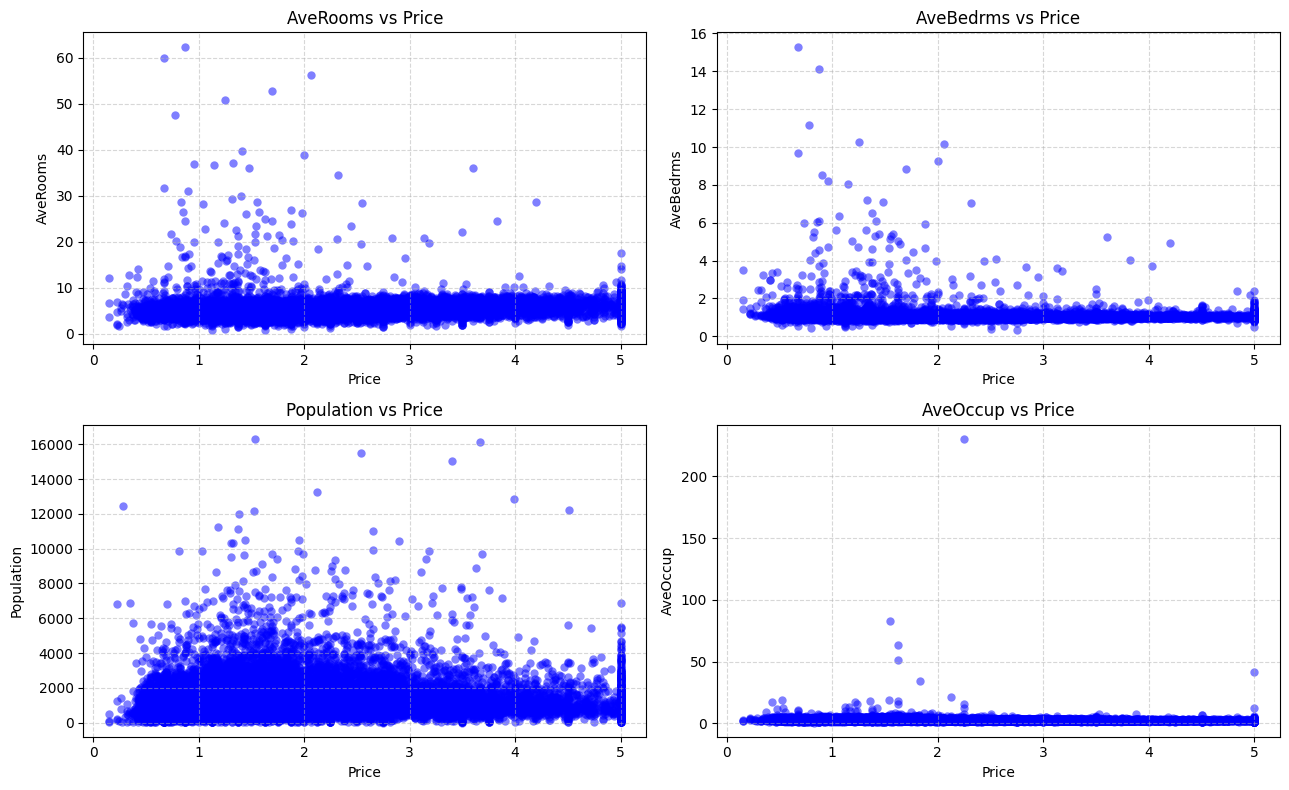

In [ ]:
# 1. グラフ描画（2行2列の散布図を作成）
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for i, col in enumerate(features):
    row = i // 2
    ax = axes[row, i % 2]

    # ★変更点：横軸(x)に各特徴量、縦軸(y)に Price を指定
    sns.scatterplot(data=train, x='Price', y=col, ax=ax, color='blue', alpha=0.5, linewidth=0)
    ax.set_title(f'{col} vs Price', fontsize=12)
    ax.set_xlabel('Price')                  # 横軸のラベルを特徴量名に
    ax.set_ylabel(col)              # 縦軸のラベルを Price に
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##### ここで、外れ値除去後のデータを保存しておく

In [ ]:
file_path_train = '/content/drive/MyDrive/house_price_competion_hoshino/1_preprocess_train_data_excluding_outliers.csv'
# 4. DataFrameをCSVとして保存
train.to_csv(file_path_train, index=False, encoding='utf-8')

#### ③特徴量の拡張

##### 3-1 特徴量拡張前の、Priceとの相関係数を確認

In [6]:
# 1. Priceとの相関係数を計算し、.abs()で全数値を絶対値（プラス）に変換
# 2. 絶対値が大きい順（降順）にソートする
price_corr_abs = train.corr()[['Price']].abs().sort_values(by='Price', ascending=False)

# 3. カラム名を「Price_Abs（絶対値）」に変更してわかりやすくする
price_corr_abs.columns = ['Price_Abs']
# 4. 結果の表示
price_corr_abs

,Price_Abs
Price,1.000000
MedInc,0.689659
AveRooms,0.157994
Latitude,0.143970
AllRooms,0.133218
HouseAge,0.108626
Household,0.063245
AveBedrms,0.058170
AllBedrms,0.047988
Longitude,0.046754


##### 2-2 特徴量の拡張

In [7]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KDTree

# =====================================================================
# 1. 固定マスタデータ・定数の定義 (関数の外に出して見通しを良くする)
# =====================================================================
CITIES = {
    'LA': (34.0522, -118.2437), 'SF': (37.7749, -122.4194),
    'SD': (32.7157, -117.1611), 'SJ': (37.3382, -121.8863),
    'SB': (34.4208, -119.6982),
}

DF_UNIV = pd.DataFrame({
    'lat': [37.8719, 37.4275, 34.1377, 34.0689, 34.0224, 38.5382, 32.8801, 34.4140],
    'lon': [-122.2585, -122.1697, -118.1253, -118.4452, -118.2851, -121.7617, -117.2340, -119.8489],
    'education_brand_score': [10, 10, 10, 9, 8, 8, 9, 8]
})

DF_CRIME = pd.DataFrame({
    'lat': [34.0116, 34.0522, 33.8958, 37.8044, 37.9358, 36.7378, 38.5816, 37.7749, 32.7157, 33.6846, 37.4419, 37.9735],
    'lon': [-118.2741,-118.2437,-118.2201,-122.2712,-122.3477,-119.7871,-121.4944,-122.4194,-117.1611,-117.8265,-122.1430,-122.5311],
    'crime_severity_index': [10.0, 9.5, 9.8, 9.6, 8.5, 7.0, 6.5, 7.5, 4.5, 1.2, 1.5, 1.8]
})

SAN_ANDREAS = np.array([
    [32.6,-115.5],[33.0,-115.8],[33.5,-116.3],[34.0,-116.8],[34.5,-117.8],
    [35.0,-118.8],[35.5,-120.0],[36.0,-120.5],[36.5,-121.0],[37.0,-121.5],
    [37.5,-121.9],[38.0,-122.2],[38.5,-122.7],[39.0,-123.1],[40.0,-124.0],
])

HAYWARD = np.array([
    [37.3,-121.9],[37.5,-122.0],[37.7,-122.1],[37.8,-122.15],[37.9,-122.2],[38.0,-122.3],
])

MILITARY_BASES = {
    'NAS_North_Island': (32.70,-117.21), 'NAS_Alameda':      (37.79,-122.30),
    'Travis_AFB':       (38.27,-121.93), 'Edwards_AFB':      (34.90,-117.88),
    'Vandenberg_AFB':   (34.74,-120.57), 'Fort_Ord':         (36.65,-121.76),
    'MCAS_El_Toro':     (33.67,-117.73), 'Point_Mugu':       (34.12,-119.12),
    'Castle_AFB':       (37.38,-120.57), 'NAS_Miramar':      (32.87,-117.14),
}

PORTS = {
    'LA_LB':   (33.74,-118.27), 'Oakland': (37.80,-122.28), 'SD': (32.73,-117.17),
}

AFFLUENT = {
    'Beverly_Hills': (34.07,-118.40), 'Palo_Alto':     (37.44,-122.15),
    'Marin':         (37.95,-122.55), 'Newport_Beach': (33.62,-117.93),
    'Santa_Barbara': (34.42,-119.70),
}

COAST = np.array([
    [41.75,-124.20],[41.00,-124.15],[40.50,-124.10],[39.80,-123.95],[39.30,-123.80],
    [38.80,-123.50],[38.30,-123.10],[37.80,-122.65],[37.50,-122.50],[37.20,-122.40],
    [36.95,-122.05],[36.50,-121.95],[36.20,-121.75],[35.65,-121.30],[35.30,-120.85],
    [34.85,-120.65],[34.45,-120.00],[34.20,-120.00],[34.20,-119.30],[34.05,-118.80],[34.05,-118.50],
    [33.85,-118.40],[33.55,-118.00],[33.20,-117.40],[32.85,-117.25],[32.65,-117.15],[32.55,-117.10],
])

COUNTY_DATA = pd.DataFrame({
    'county': [
        'San Francisco','Marin','San Mateo','Santa Clara','Alameda',
        'Contra Costa','Sonoma','Napa','Solano','Sacramento',
        'Yolo','Placer','El Dorado','Los Angeles','Orange',
        'San Diego','Ventura','Santa Barbara','San Luis Obispo','Monterey',
        'Santa Cruz','San Joaquin','Stanislaus','Merced','Fresno',
        'Tulare','Kings','Kern','San Bernardino','Riverside','Imperial',
    ],
    'lat': [
        37.77, 37.95, 37.56, 37.33, 37.65, 37.92, 38.44, 38.29, 38.27, 38.58,
        38.69, 38.89, 38.77, 34.05, 33.72, 32.86, 34.27, 34.70, 35.55, 36.24,
        36.97, 37.94, 37.56, 37.19, 36.78, 36.22, 36.10, 35.37, 34.10, 33.95, 33.04,
    ],
    'lon': [
        -122.42,-122.55,-122.31,-121.89,-121.87,-122.00,-122.72,-122.28,-122.00,-121.49,
        -121.90,-120.80,-120.52,-118.24,-117.83,-117.10,-119.23,-119.70,-120.65,-121.60,
        -121.98,-121.27,-121.00,-120.72,-119.79,-119.00,-119.82,-119.02,-117.29,-117.39,-115.37,
    ],
    'edu_score':     [9,10,9,10,8,8,7,7,6,7,9,8,8,6,8,8,8,8,8,6,8,5,5,4,4,3,3,4,5,5,3],
    'poverty_score': [4,2,2,2,4,3,3,3,4,5,4,2,2,6,3,4,3,4,3,6,4,7,7,8,8,9,9,8,7,7,10],
    'unemp_score':   [3,2,2,2,4,3,4,3,5,5,4,3,3,6,3,4,3,4,4,5,4,7,6,8,8,8,8,7,6,6,9],
})

BART_STATIONS = np.array([
    [37.937,-122.353],[37.925,-122.317],[37.902,-122.299],[37.874,-122.283],
    [37.870,-122.268],[37.853,-122.270],[37.829,-122.267],[37.808,-122.269],
    [37.804,-122.272],[37.798,-122.265],[37.775,-122.224],[37.754,-122.198],
    [37.722,-122.161],[37.697,-122.127],[37.670,-122.088],[37.635,-122.057],
    [37.591,-122.017],[37.557,-121.977],
    [37.973,-122.029],[37.948,-122.057],[37.905,-122.067],[37.893,-122.124],
    [37.878,-122.183],[37.844,-122.251],[37.805,-122.295],
    [37.793,-122.397],[37.789,-122.401],[37.784,-122.408],[37.780,-122.415],
    [37.765,-122.419],[37.752,-122.419],[37.733,-122.434],[37.722,-122.447],
    [37.706,-122.469],
])

CALTRAIN_STATIONS = np.array([
    [37.776,-122.394],[37.758,-122.392],[37.709,-122.401],[37.654,-122.444],
    [37.630,-122.411],[37.600,-122.387],[37.580,-122.345],[37.567,-122.323],
    [37.553,-122.309],[37.537,-122.296],[37.521,-122.276],[37.508,-122.260],
    [37.486,-122.232],[37.464,-122.198],[37.454,-122.182],[37.444,-122.165],
    [37.430,-122.143],[37.407,-122.107],[37.394,-122.077],[37.378,-122.031],
    [37.371,-121.997],[37.353,-121.936],[37.330,-121.902],[37.312,-121.883],
    [37.133,-121.654],[37.086,-121.613],[37.005,-121.567],
])

LA_METRO_BLUE = np.array([
    [34.048,-118.259],[34.037,-118.265],[34.026,-118.268],[34.018,-118.267],
    [33.979,-118.269],[33.975,-118.266],[33.964,-118.261],[33.957,-118.253],
    [33.940,-118.245],[33.921,-118.239],[33.898,-118.221],[33.866,-118.205],
    [33.843,-118.197],[33.823,-118.200],[33.804,-118.191],[33.769,-118.190],
])

DEFENSE_PLANTS = {
    'Lockheed_Palmdale':       (34.58, -118.08), 'Lockheed_Burbank':        (34.18, -118.33),
    'Lockheed_Sunnyvale':      (37.39, -122.03), 'Northrop_Hawthorne':      (33.92, -118.33),
    'McDonnell_Douglas_LB':    (33.82, -118.19), 'Raytheon_ElSegundo':      (33.92, -118.40),
    'Rockwell_Downey':         (33.94, -118.13), 'Hughes_Aircraft_Culver':  (34.00, -118.40),
    'TRW_Redondo':             (33.86, -118.37), 'General_Dynamics_Pomona': (34.06, -117.75),
    'Aerojet_Sacramento':      (38.55, -121.38), 'Lawrence_Livermore':      (37.69, -121.70),
    'Loral_SanJose':           (37.33, -121.89), 'Rockwell_Seal_Beach':     (33.74, -118.10),
}

AIR_QUALITY_REFS = pd.DataFrame({
    'lat': [33.98, 34.11, 35.37, 36.75, 34.09, 34.05, 34.15, 34.07, 33.77, 34.18, 34.02, 37.77, 37.80, 37.34, 34.42, 32.72, 36.60, 38.58, 40.80],
    'lon': [-117.37, -117.29, -119.02, -119.77, -117.43, -118.24, -118.14, -118.03, -118.19, -118.31, -118.49, -122.42, -122.27, -121.89, -119.70, -117.16, -121.90, -121.49, -124.16],
    'smog_score': [10, 9, 10, 9, 9, 7, 8, 8, 7, 7, 4, 3, 4, 4, 3, 4, 2, 5, 1]
})

# KDTree の共通初期化
UNIV_TREE = KDTree(DF_UNIV[['lat', 'lon']].values)
CRIME_TREE = KDTree(DF_CRIME[['lat', 'lon']].values)
COUNTY_TREE = KDTree(COUNTY_DATA[['lat', 'lon']].values)
AQ_TREE = KDTree(AIR_QUALITY_REFS[['lat', 'lon']].values)


# =====================================================================
# 2. 距離計算ロジック
# =====================================================================
def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return c * 6371

def _get_min_dist(lats, lons, points_array):
    """複数地点の座標配列に対する最小ハバーシン距離を一括計算するヘルパー"""
    dists = np.column_stack([haversine_distance(lats, lons, p[0], p[1]) for p in points_array])
    return dists.min(axis=1)


# =====================================================================
# 3. メイン特徴量生成関数
# =====================================================================
def add_features(train_df, test_df):
    X_tr = train_df.copy()
    X_te = test_df.copy()

    # 目的変数の分離
    y_tr = X_tr['Price'].copy()
    X_tr = X_tr.drop(columns=['Price'])

    # ガウス混合モデル (GMM) の学習 (データリーク防止のためTrainのみでfit)
    gmm = GaussianMixture(n_components=15, covariance_type='full', random_state=42)
    gmm.fit(X_tr[['Latitude', 'Longitude']])

    # 共通カラム定義
    dist_cols = [f'dist_{c}' for c in CITIES]

    # --- それぞれの DataFrame にループで同じ処理を追加 ---
    for df in [X_tr, X_te]:
        lats = df['Latitude'].values
        lons = df['Longitude'].values
        coords = df[['Latitude', 'Longitude']].values
        
        # タイピング量削減と可読性向上のためのショートカット
        lat, lon = df['Latitude'], df['Longitude']

        # 1. 比率・相互作用特徴量
        df['rooms_per_person']     = df['AveRooms']  / (df['AveOccup']  + 1e-3)
        df['bedrooms_ratio']       = df['AveBedrms'] / (df['AveRooms']  + 1e-3)
        df['income_per_room']      = df['MedInc']    / (df['AveRooms']  + 1e-3)
        df['rooms_per_household']  = df['AllRooms']  / (df['Household'] + 1e-3)
        df['bedrms_per_household'] = df['AllBedrms'] / (df['Household'] + 1e-3)
        df['total_income_proxy']   = df['MedInc']    * df['Household']
        df['nonbedroom_rooms']     = df['AveRooms']  -  df['AveBedrms']
        df['household_density']    = df['Household'] / (df['AllRooms']  + 1e-3)

        # 2. 主要都市距離
        for city, (clat, clon) in CITIES.items():
            df[f'dist_{city}'] = haversine_distance(lats, lons, clat, clon)
        df['dist_nearest_city'] = df[dist_cols].min(axis=1)
        df['coast_dist_proxy']  = df[['dist_SF', 'dist_LA', 'dist_SD']].min(axis=1)

        # 3. 名門大学インデックス
        univ_dists, univ_idx = UNIV_TREE.query(coords, k=1)
        univ_idx = univ_idx.flatten()
        df['dist_to_elite_univ']       = univ_dists.flatten()
        df['nearest_univ_brand_score'] = DF_UNIV['education_brand_score'].iloc[univ_idx].values
        df['univ_influence_score']     = df['nearest_univ_brand_score'] / (df['dist_to_elite_univ'] + 1e-2)

        # 4. 1990年治安リスクインデックス
        crime_dists, crime_idx = CRIME_TREE.query(coords, k=1)
        crime_idx = crime_idx.flatten()
        df['nearest_crime_idx_1990']  = DF_CRIME['crime_severity_index'].iloc[crime_idx].values
        df['dist_to_crime_benchmark'] = crime_dists.flatten()
        df['local_crime_exposure']    = df['nearest_crime_idx_1990'] / (df['dist_to_crime_benchmark'] + 1e-2)

        # 5. 地震リスク
        df['dist_san_andreas']   = _get_min_dist(lats, lons, SAN_ANDREAS)
        df['dist_hayward_fault'] = _get_min_dist(lats, lons, HAYWARD)
        df['min_fault_dist']     = np.minimum(df['dist_san_andreas'], df['dist_hayward_fault'])
        df['seismic_risk_score'] = 1.0 / (df['min_fault_dist'] + 1.0)

        # 6. 軍事基地
        mil_cols = [f'dist_mil_{base}' for base in MILITARY_BASES]
        for col, (blat, blon) in zip(mil_cols, MILITARY_BASES.values()):
            df[col] = haversine_distance(lats, lons, blat, blon)
        df['dist_nearest_military'] = df[mil_cols].min(axis=1)

        # 7. 港湾アクセス
        port_cols = [f'dist_port_{port}' for port in PORTS]
        for col, (plat, plon) in zip(port_cols, PORTS.values()):
            df[col] = haversine_distance(lats, lons, plat, plon)
        df['dist_nearest_port'] = df[port_cols].min(axis=1)

        # 8. シリコンバレー雇用圏 / 9. メキシコ国境
        df['dist_silicon_valley'] = haversine_distance(lats, lons, 37.39, -122.05)
        df['dist_mexico_border']  = haversine_distance(lats, lons, 32.54, -117.03)

        # 10. 高所得住宅地への引力
        aff_cols = [f'dist_aff_{area}' for area in AFFLUENT]
        for col, (alat, alon) in zip(aff_cols, AFFLUENT.values()):
            df[col] = haversine_distance(lats, lons, alat, alon)
        df['dist_nearest_affluent'] = df[aff_cols].min(axis=1)
        df['affluent_gravity']      = 1.0 / (df['dist_nearest_affluent'] + 1.0)

        # 11. 経済地帯フラグ (エイリアス lat, lon を使って簡潔に記述)
        df['zone_bay_area']        = ((lat > 37.0) & (lat < 38.5) & (lon > -122.8) & (lon < -121.4)).astype(int)
        df['zone_la_basin']        = ((lat > 33.6) & (lat < 34.5) & (lon > -118.8) & (lon < -117.5)).astype(int)
        df['zone_san_diego']       = (lat < 33.2).astype(int)
        df['zone_central_valley']  = ((lon > -121.8) & (lon < -118.5) & (lat > 35.0) & (lat < 38.5)).astype(int)
        df['zone_inland_empire']   = ((lat > 33.8) & (lat < 34.3) & (lon > -117.8) & (lon < -116.9)).astype(int)
        df['zone_orange_county']   = ((lat > 33.4) & (lat < 34.0) & (lon > -118.0) & (lon < -117.4)).astype(int)

        # 12. NorCal/SoCal分断 / 13. Kern County石油地帯
        df['is_norcal']     = (lat > 35.5).astype(int)
        df['is_socal']      = (lat < 34.5).astype(int)
        df['dist_kern_oil'] = haversine_distance(lats, lons, 35.37, -119.02)

        # 14. 精密海岸線距離
        df['coast_dist_precise'] = _get_min_dist(lats, lons, COAST)

        # 15. 所得×地域フラグの交互作用
        df['income_x_bay']    = df['MedInc'] * df['zone_bay_area']
        df['income_x_la']     = df['MedInc'] * df['zone_la_basin']
        df['income_x_norcal'] = df['MedInc'] * df['is_norcal']

        # 16. 郡レベル教育・貧困・失業スコア
        _, county_idx = COUNTY_TREE.query(coords, k=1)
        county_idx = county_idx.flatten()
        df['county_edu_score']     = COUNTY_DATA['edu_score'].iloc[county_idx].values
        df['county_poverty_score'] = COUNTY_DATA['poverty_score'].iloc[county_idx].values
        df['county_unemp_score']   = COUNTY_DATA['unemp_score'].iloc[county_idx].values
        df['county_quality_idx']   = df['county_edu_score'] - 0.6 * df['county_poverty_score'] - 0.4 * df['county_unemp_score']
        df['income_x_county_edu']  = df['MedInc'] * df['county_edu_score']

        # 17. 公共交通機関への距離
        df['dist_nearest_bart']     = _get_min_dist(lats, lons, BART_STATIONS)
        df['dist_nearest_caltrain'] = _get_min_dist(lats, lons, CALTRAIN_STATIONS)
        df['dist_nearest_metro']    = _get_min_dist(lats, lons, LA_METRO_BLUE)
        df['dist_nearest_transit']  = np.minimum(np.minimum(df['dist_nearest_bart'], df['dist_nearest_caltrain']), df['dist_nearest_metro'])
        df['in_transit_walkzone']   = (df['dist_nearest_transit'] < 2.0).astype(int)
        df['in_bart_walkzone']      = (df['dist_nearest_bart']    < 2.0).astype(int)
        df['transit_access_score']  = 1.0 / (df['dist_nearest_transit'] + 1.0)

        # 18. 主要都市への方向 (ループ処理で綺麗にまとめる)
        df['lat_plus_lon']  = lat + lon
        df['lat_minus_lon'] = lat - lon
        for city in ['LA', 'SF', 'SD']:
            df[f'angle_to_{city.lower()}'] = np.arctan2(lat - CITIES[city][0], lon - CITIES[city][1])
        df['lat_lon_inter'] = lat * lon

        # 19. Geo-cluster エリア予測
        df['geo_cluster'] = gmm.predict(coords)

        # 20. 防衛産業クラスター
        def_cols = [f'dist_def_{plant}' for plant in DEFENSE_PLANTS]
        for col, (plat, plon) in zip(def_cols, DEFENSE_PLANTS.values()):
            df[col] = haversine_distance(lats, lons, plat, plon)
        df['dist_nearest_defense']   = df[def_cols].min(axis=1)
        df['defense_cluster_score']  = 1.0 / (df['dist_nearest_defense'] + 1.0)
        df['defense_top3_mean_dist'] = df[def_cols].apply(lambda r: np.mean(sorted(r.values)[:3]), axis=1)

        # 21. 大気汚染スコア
        aq_dists, aq_idx = AQ_TREE.query(coords, k=3)
        aq_w = 1.0 / (aq_dists + 1e-3)
        aq_w /= aq_w.sum(axis=1, keepdims=True)
        df['smog_score_1990'] = (AIR_QUALITY_REFS['smog_score'].values[aq_idx] * aq_w).sum(axis=1)
        df['smog_x_coast']    = df['smog_score_1990'] * df['coast_dist_precise']

    # 22. 地域（geo_cluster）ごとの統計量・差分特徴量の生成 (共通化してスッキリ記述)
    for col in ['MedInc', 'AveRooms', 'HouseAge']:
        cluster_means = X_tr.groupby('geo_cluster', observed=False)[col].mean()
        for target_df in [X_tr, X_te]:
            target_df[f'{col}_cluster_mean'] = target_df['geo_cluster'].map(cluster_means)
            target_df[f'{col}_diff_from_cluster_mean'] = target_df[col] - target_df[f'{col}_cluster_mean']

    # 出力用カラムの抽出と整形（'id' を除外）
    feature_cols = [c for c in X_tr.columns if c != 'id']
    
    return X_tr[feature_cols].reset_index(drop=True), y_tr, X_te[feature_cols].reset_index(drop=True)

# 呼び出し
x_train, y_train, test = add_features(train, test)

#説明変数と目的変数を結合してtrainデータを再構築
train = pd.concat([x_train, y_train], axis=1)

# 生成した geo_cluster をカテゴリ型に変換してメモリ削減
train['geo_cluster'] = train['geo_cluster'].astype('category')
test['geo_cluster'] = test['geo_cluster'].astype('category')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(
/tmp/ipykernel_7408/1899046504.py:304: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['smog_score_1990'] = (AIR_QUALITY_REFS['smog_score'].values[aq_idx] * aq_w).sum(axis=1)
/tmp/ipykernel_7408/1899046504.py:305: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['smog_x_coast']    = df['smog_score_1990'] * df['coast_dist_precise']
/usr/loca

##### 2-3 特徴量拡張後の、住宅価格との相関係数確認

In [10]:
# 1. Priceとの相関係数を計算し、.abs()で全数値を絶対値（プラス）に変換
# 2. 絶対値が大きい順（降順）にソートする
price_corr_abs = train.corr()[['Price']].abs().sort_values(by='Price', ascending=False)

# 3. カラム名を「Price_Abs（絶対値）」に変更してわかりやすくする
price_corr_abs.columns = ['Price_Abs']
# 4. 結果の表示
price_corr_abs

,Price_Abs
Price,1.000000
income_x_county_edu,0.701062
MedInc,0.689659
income_per_room,0.662105
MedInc_diff_from_cluster_mean,0.549492
...,...
dist_aff_Marin,0.019447
nearest_crime_idx_1990,0.018645
angle_to_la,0.017352
dist_def_Lawrence_Livermore,0.008643


##### 2-4 富裕層確率スタッキングの拡張

In [ ]:
# ==========================================
# 9. 富裕層確率スタッキング（メタ特徴量）
# ==========================================
import warnings
import lightgbm as lgb
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.neighbors import KDTree

if "Price" in train.columns:
  print("富裕層確率スタッキング（メタ特徴量）を生成中...")
  max_price = train["Price"].max()
  y_clip = (train["Price"] >= (max_price - 0.01)).astype(int)

  stack_drop_cols = ["id", "Price"]
  feature_cols = [
      c for c in train.columns if c not in stack_drop_cols
  ]

  X_stack = train[feature_cols].values
  X_test_stack = test[feature_cols].values

  oof_stack_preds = np.zeros(len(train))
  test_stack_preds = np.zeros(len(test))

  kf_stack = KFold(n_splits=5, shuffle=True, random_state=42)

  for train_idx, val_idx in kf_stack.split(X_stack):
      X_tr, X_val = X_stack[train_idx], X_stack[val_idx]
      y_tr, y_val = y_clip.iloc[train_idx], y_clip.iloc[val_idx]

      clf = LGBMClassifier(
          n_estimators=500,
          learning_rate=0.05,
          max_depth=5,
          num_leaves=31,
          random_state=42,
          n_jobs=-1,
          verbose=-1,
      )
      clf.fit(
          X_tr,
          y_tr,
          eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
      )

      oof_stack_preds[val_idx] = clf.predict_proba(X_val)[:, 1]
      test_stack_preds += (
          clf.predict_proba(X_test_stack)[:, 1] / kf_stack.n_splits
      )

  train["Rich_Probability_Stacking"] = oof_stack_preds
  test["Rich_Probability_Stacking"] = test_stack_preds

富裕層確率スタッキング（メタ特徴量）を生成中...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [11]:
# ファイルパスの指定
file_path_train = '/content/drive/MyDrive/house_price_competition_hoshino/data/2_preprocess_train_data_add_feature.csv'
file_path_test = '/content/drive/MyDrive/house_price_competition_hoshino/data/1_preprocess_test_data_add_feature.csv'
# DataFrameをCSVとして保存
train.to_csv(file_path_train, index=False, encoding='utf-8')
test.to_csv(file_path_test, index=False, encoding='utf-8')

#### 目的変数の対数変換・Box-Cox変換

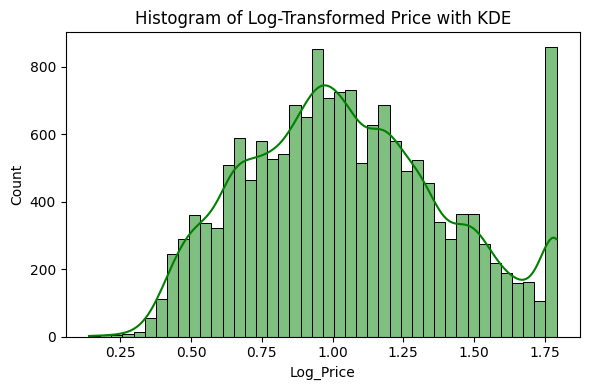

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Priceデータを対数変換して新しいカラム「Log_Price」を作成
train['Log_Price'] = np.log1p(train['Price'])

# 2. 変換後の分布をヒストグラムで確認
fig, ax = plt.subplots(figsize=(6, 4))

# 対数変換後のヒストグラム（KDE曲線付き）
sns.histplot(train['Log_Price'], kde=True, ax=ax, color='green')
ax.set_title('Histogram of Log-Transformed Price with KDE')

plt.tight_layout()
plt.show()

■ 最適化されたラムダ (λ) の値: 0.1249
------------------------------------------------------------


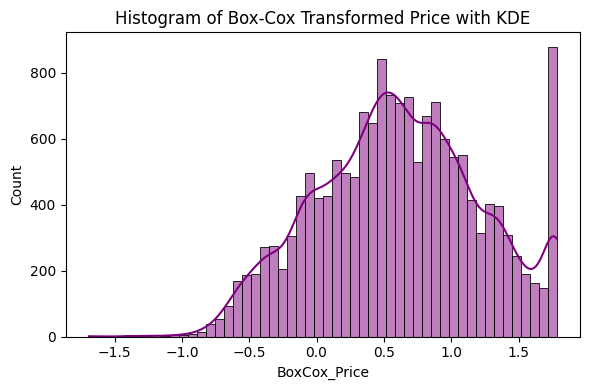

In [ ]:
from scipy import stats  # 必須：statsモジュールをインポート

# 1. PriceデータをBox-Cox変換して新しいカラム「BoxCox_Price」を作成
# ※stats.boxcoxは「変換後のデータ」と「最適化されたラムダ（λ）」の2つを返します
train['BoxCox_Price'], maxlog = stats.boxcox(train['Price'])

print(f"■ 最適化されたラムダ (λ) の値: {maxlog:.4f}")
print("-" * 60)

# 2. 変換後の分布をヒストグラムで確認
fig, ax = plt.subplots(figsize=(6, 4))

# Box-Cox変換後のヒストグラム（KDE曲線付き）
sns.histplot(train['BoxCox_Price'], kde=True, ax=ax, color='purple')
ax.set_title('Histogram of Box-Cox Transformed Price with KDE')

plt.tight_layout()
plt.show()

In [ ]:
file_path_train = '/content/drive/MyDrive/house_price_competion_hoshino/3_preprocess_train_data_translate_log&box-cox.csv'
# 4. DataFrameをCSVとして保存
train.to_csv(file_path_train, index=False, encoding='utf-8')